In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [45]:
# Load the dataset
df = pd.read_csv('student_performance_dataset.csv')

df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [47]:
# Drop columns that are not useful for predicting the exact score
df = df.drop(columns=['Student_ID', 'Pass_Fail'])

df.head()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score
0,Male,31,68.267841,86,High School,Yes,Yes,63
1,Male,16,78.222927,73,PhD,No,No,50
2,Female,21,87.525096,74,PhD,Yes,No,55
3,Female,27,92.076483,99,Bachelors,No,No,65
4,Female,37,98.655517,63,Masters,No,Yes,70


In [49]:
# df.groupby('Parental_Education_Level')['Final_Exam_Score'].mean()

# df.groupby('Parental_Education_Level')['Final_Exam_Score'].min()

df.groupby('Parental_Education_Level')['Final_Exam_Score'].max()

Parental_Education_Level
Bachelors      77
High School    73
Masters        74
PhD            71
Name: Final_Exam_Score, dtype: int64

In [51]:
# List of categorical columns in your dataset
categorical_cols = ['Gender', 'Parental_Education_Level', 
                    'Internet_Access_at_Home', 'Extracurricular_Activities']

# Convert categorical variables into dummy/indicator variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score,Gender_Male,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes
0,31,68.267841,86,63,True,True,False,False,True,True
1,16,78.222927,73,50,True,False,False,True,False,False
2,21,87.525096,74,55,False,False,False,True,True,False
3,27,92.076483,99,65,False,False,False,False,False,False
4,37,98.655517,63,70,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
703,14,84.658761,78,50,True,False,False,True,True,False
704,35,60.278990,83,62,True,False,True,False,False,False
705,25,98.384969,75,57,True,False,False,False,True,False
706,21,96.148012,84,65,False,False,False,False,True,False


In [53]:
# Define Features (X) and Target (y)
X = df_encoded.drop('Final_Exam_Score', axis=1)
y = df_encoded['Final_Exam_Score']

# Split the dataset into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features ready for modeling: {list(X.columns)}")

Features ready for modeling: ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Gender_Male', 'Parental_Education_Level_High School', 'Parental_Education_Level_Masters', 'Parental_Education_Level_PhD', 'Internet_Access_at_Home_Yes', 'Extracurricular_Activities_Yes']


In [55]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [57]:

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
}).sort_values(by='Weight', ascending=False)

print(f"Base Score (Intercept): {model.intercept_:.2f}\n")
print(coefficients.to_string(index=False))

Base Score (Intercept): 16.23

                             Feature    Weight
      Extracurricular_Activities_Yes  0.847250
                Study_Hours_per_Week  0.275259
                    Past_Exam_Scores  0.235153
                     Attendance_Rate  0.224277
                         Gender_Male  0.085047
    Parental_Education_Level_Masters -0.325939
        Parental_Education_Level_PhD -0.393319
         Internet_Access_at_Home_Yes -0.857995
Parental_Education_Level_High School -1.222472


In [59]:
# Make predictions on the testing data
y_pred = model.predict(X_test)

comparison_df = pd.DataFrame({
    'Actual_Value (y_test)': y_test.reset_index(drop=True),
    'Predicted_Value (y_pred)': y_pred
})
comparison_df

,Actual_Value (y_test),Predicted_Value (y_pred)
0,50,47.460094
1,65,63.974954
2,68,64.238697
3,60,64.825896
4,64,63.246785
...,...,...
137,56,61.484441
138,52,55.907309
139,52,55.640898
140,63,59.510404


In [61]:


# Calculate Accuracy Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("--- Evaluation Metrics ---")
print(f"R-squared: {r2:.4f} (The model explains {r2*100:.1f}% of the variance)")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} points")

--- Evaluation Metrics ---
R-squared: 0.6523 (The model explains 65.2% of the variance)
Root Mean Squared Error (RMSE): 3.85 points


C:\Users\manga\AppData\Local\Temp\ipykernel_8996\1070078866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=coefficients, palette='coolwarm',legend=True)


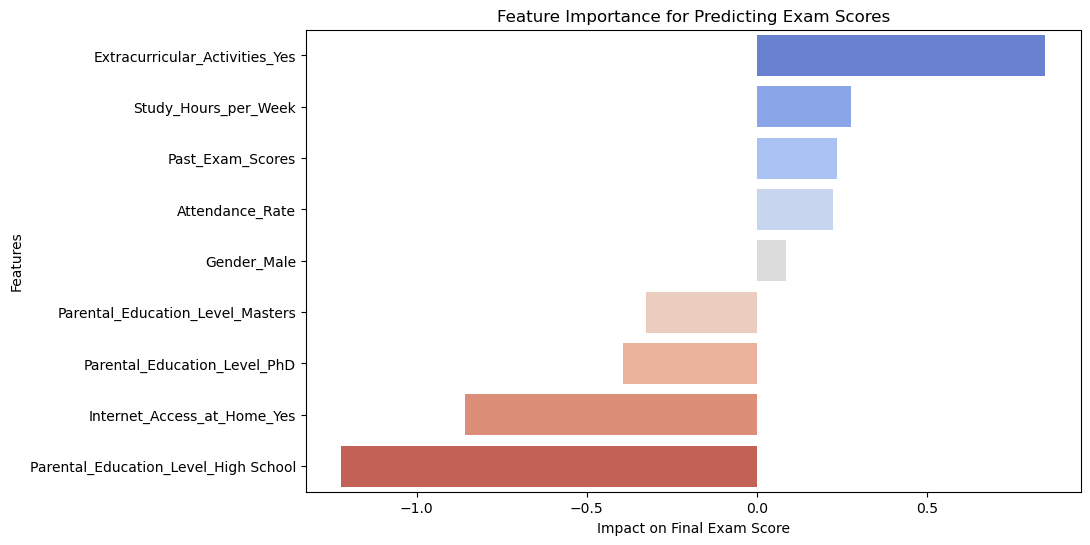

In [75]:
# Plot which factors have the biggest impact on the Final Exam Score
plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=coefficients, palette='coolwarm',legend=True)
plt.title('Feature Importance for Predicting Exam Scores')
plt.xlabel('Impact on Final Exam Score')
plt.ylabel('Features')
plt.show()